In [2]:
#----- Import libraries ----------------------------------------------------------------------------------------------------------------------------------------------------

import numpy as np # array-processing package
import pandas as pd # data analysis toolkit
import matplotlib.pyplot as plt # static, animated and interactive visualizations
import seaborn as sns # data visualization library
import re # regular expressions
from sklearn.metrics.pairwise import cosine_similarity # computes cosine similarity between samples
from sklearn.preprocessing import StandardScaler # standardizes features by removing the mean and scaling to unit variance
from scipy.sparse import csr_matrix # sparse matrix package for numeric data
from scipy.stats import pearsonr # computes the pearson correlation coefficient
from scipy.sparse.linalg import svds # singular value decomposition for matrix factorization
from sklearn.metrics import mean_squared_error, mean_absolute_error, precision_score, recall_score, f1_score # evaluation metrics
from sklearn.model_selection import train_test_split # splits arrays or matrices into random train and test subsets
from datetime import date, datetime
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer # for text data tokenization
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.metrics.pairwise import linear_kernel # for similarity calculation
from sklearn.decomposition import TruncatedSVD
from difflib import get_close_matches
plt.style.use('ggplot') # estilo dos gráficos
pd.set_option('display.max_columns', 200) # quantidade de colunas que aparecem do nosso dataset

In [4]:
#----- Load the datasets ----------------------------------------------------------------------------------------------------------------------------------------------------

dataset_movies = pd.read_csv('../datasets/imdb_movies.csv', sep = ';', encoding = 'ISO-8859-1')
# coloquei encoding='ISO-8859-1' porque existem caracteres especiais no dataset que impedem que ele corra em UTF-8

dataset_ratings = pd.read_csv('../datasets/imdb_ratings.csv', sep = ';')
# este já não precisou de um encoding diferente, porque é um dataset numérico

#----- Merge the datasets ----------------------------------------------------------------------------------------------------------------------------------------------------

datajoin = pd.concat([dataset_movies, dataset_ratings], axis = 1)


#----- Dataset Analysis ----------------------------------------------------------------------------------------------------------------------------------------------------

#print(datajoin.shape) # temos inicialmente 85855 linhas e 71 colunas
#print(datajoin.head(20)) # 20 primeiras linhas do dataset
# como o pd por defeito não nos deixa ver as colunas todas e estamos a obter "imdb_title_id  ... non_us_voters_votes",
# então ativamos a condicao das linhas iniciais: pd.set_option('display.max_columns', 200)
#print(datajoin.columns) # nome das colunas
#print(datajoin.dtypes) # tipo de variáveis de cada coluna

#print(datajoin.describe) # similar aos outros

In [5]:
#----- Columns Treatment ----------------------------------------------------------------------------------------------------------------------------------------------------

# RETIRAR COLUNAS DESNECESSÁRIAS PARA O CASO DE ESTUDO
df = datajoin[[#'imdb_title_id',
        'title', 'original_title',
        'year', 'date_published', 'genre', 'duration',
        'country', 'language', 'director', 'writer', 'production_company', 'actors',
        'description',
        'avg_vote', 'votes',
        #'budget', 'usa_gross_income', 'worlwide_gross_income', 'metascore',
        #'reviews_from_users', 'reviews_from_critics',
        #'imdb_title_id',
        'weighted_average_vote', 'total_votes', 'mean_vote', 'median_vote',
        'votes_10', 'votes_9', 'votes_8', 'votes_7', 'votes_6', 'votes_5',
        'votes_4', 'votes_3', 'votes_2', 'votes_1',
        #'allgenders_0age_avg_vote', 'allgenders_0age_votes',
        'allgenders_18age_avg_vote',
        'allgenders_18age_votes', 'allgenders_30age_avg_vote',
        'allgenders_30age_votes', 'allgenders_45age_avg_vote',
        'allgenders_45age_votes', 'males_allages_avg_vote',
        'males_allages_votes',
        #'males_0age_avg_vote', 'males_0age_votes',
        'males_18age_avg_vote', 'males_18age_votes', 'males_30age_avg_vote',
        'males_30age_votes', 'males_45age_avg_vote', 'males_45age_votes',
        'females_allages_avg_vote', 'females_allages_votes',
        #'females_0age_avg_vote', 'females_0age_votes',
        'females_18age_avg_vote', 'females_18age_votes', 'females_30age_avg_vote', 'females_30age_votes',
        'females_45age_avg_vote', 'females_45age_votes',
        'top1000_voters_rating', 'top1000_voters_votes', 'us_voters_rating',
        'us_voters_votes', 'non_us_voters_rating', 'non_us_voters_votes']]

# retirei as colunas que não faziam sentido para o estudo que vamos fazer ou repetidas
# (provavelmente ainda vale a pena tirar mais) - mantive assim para ter nocao do que foi
# retirado




# RENOMEAR AS COLUNAS
df = df.rename(columns = {'allgenders_18age_avg_vote' : 'allgenders_18_to_30_avg_vote',
        'allgenders_18age_votes' : 'allgenders_18_to_30_votes',
        'allgenders_30age_avg_vote' : 'allgenders_30_to_45_avg_vote',
        'allgenders_30age_votes' : 'allgenders_30_to_45_votes',
        'allgenders_45age_avg_vote' : 'allgenders_45_and_above_avg_vote',
        'allgenders_45age_votes' : 'allgenders_45_and_above_votes',
        'males_18age_avg_vote' : 'males_18_to_30_avg_vote',
        'males_18age_votes' : 'males_18_to_30_votes',
        'males_30age_avg_vote' : 'males_30_to_45_avg_vote',
        'males_30age_votes' : 'males_30_to_45_votes',
        'males_45age_avg_vote' : 'males_45_and_above_avg_vote',
        'males_45age_votes' : 'males_45_and_above_votes',
        'females_18age_avg_vote' : 'females_18_to_30_avg_vote',
        'females_18age_votes' : 'females_18_to_30_votes',
        'females_30age_avg_vote' : 'females_30_to_45_avg_vote',
        'females_30age_votes' : 'females_30_to_45_votes',
        'females_45age_avg_vote' : 'females_45_and_above_avg_vote',
        'females_45age_votes' : 'females_45_and_above_votes'})

In [6]:
#----- Handle missing values ----------------------------------------------------------------------------------------------------------------------------------------------------

print(df.isna().sum()) # aqui sabemos quantos missing values temos em cada coluna

# MISSING VALUES - COLUNA YEAR:

#print(df['year'].isnull().sum()) # existe 1 missing value na coluna 'year'
ind_missval_year = df[df['year'].isnull()].index[0] # a linha onde está o missing value é a 83917

# o missing value de 'year' pode ser substituído pelo valor da coluna 'date_published:
valor_date_published = df.at[ind_missval_year, 'date_published']  # Obtém o valor da coluna 'date_published'
                                                                  # neste índice

# Usamos uma expressão regular para extrair o ano, porque o resultado era TV Movie 2019 e só queremos o 2019
ano = re.search(r'\b\d{4}\b', valor_date_published)

# Se o ano for encontrado, substituir o valor na coluna 'year'
if ano:
    df.at[ind_missval_year, 'year'] = int(ano.group())  # Substitui o valor de 'year' com o ano extraído, ou seja, não
                                                        # existem mais missing values na coluna 'year'

df = df.astype({'year' : 'int'}) # evita que os números apareçam como floats




# MISSING VALUES - COLUNAS A PREENCHAR:

coluna_inicio = 'avg_vote'  # A partir de onde é para preencher os missing values baseado numa regra

colunas_a_preencher = df.loc[:, coluna_inicio:].columns # pegar em todas as colunas a partir da 'coluna_inicio'
                                                        # para saber o que temos de preencher

df[colunas_a_preencher] = df[colunas_a_preencher].fillna(df[colunas_a_preencher].mean())

# Complement country and language
# Note: agg() applies a function to the group; lambda is an anonymous function; empty checks if the mode is empty
country_mode_per_language = datajoin.groupby("language")["country"].agg(lambda x: x.mode()[0] if not x.mode().empty else "NA")
language_mode_per_country = datajoin.groupby("country")["language"].agg(lambda x: x.mode()[0] if not x.mode().empty else "NA")


# Fill country with the mode of language
# Note: .map() maps values of series according to input correspondence
datajoin.loc[datajoin["country"].isna(), "country"] = datajoin["language"].map(country_mode_per_language)
# Fill language with the mode of country
datajoin.loc[datajoin["language"].isna(), "language"] = datajoin["country"].map(language_mode_per_country)
# Fill the remaining missing values with NA
datajoin.fillna({"country": "NA", "language": "NA"}, inplace = True)

title                                  0
original_title                         0
year                                   1
date_published                         0
genre                                  0
duration                               0
country                               64
language                             901
director                              87
writer                              1572
production_company                  4455
actors                                69
description                         2115
avg_vote                               0
votes                                  0
weighted_average_vote                  0
total_votes                            0
mean_vote                              0
median_vote                            0
votes_10                               0
votes_9                                0
votes_8                                0
votes_7                                0
votes_6                                0
votes_5         

In [7]:
#----- Handle data types ----------------------------------------------------------------------------------------------------------------------------------------------------

#Tratamento de floats
for coluna in datajoin.select_dtypes(include=["float64"]).columns:
    datajoin[coluna] = datajoin[coluna].astype("float32")
    #if re.search(r"avg|rating|metascore|mean", coluna): 
        #datajoin[coluna] = datajoin[coluna].astype("float16")
    #else: 
        #datajoin[coluna] = datajoin[coluna].astype("int64")

#Tratamento de inteiros
for coluna in datajoin.select_dtypes(include=["int64"]).columns:
    minimo = datajoin[coluna].min()
    maximo = datajoin[coluna].max()
    if minimo >= -128 and maximo <= 127:
        datajoin[coluna] = datajoin[coluna].astype("int8")
    elif minimo >= -32768 and maximo <= 32767:
        datajoin[coluna] = datajoin[coluna].astype("int16")
    elif minimo >= -2147483648 and maximo <= 2147483647:
        datajoin[coluna] = datajoin[coluna].astype("int32")

In [8]:
# TRATAMENTO DE DADOS - COLUNA DATE_PUBLISHED:

# Nesta parte decidi trabalhar nas datas da coluna date_published. Tinha algumas datas que estavam invertidas, por exemplo
# 1894-10-09 e outras que só tinham o ano, por exemplo, 2019. Assim, inverti as que estavam invertidas inicialmente e as que
# só tinham o ano passaram a ser 01-01-2019

# Função para verificar se a string está no formato dd-mm-yyyy
def is_valid_date_format(date_str):
    return bool(re.match(r'^\d{2}-\d{2}-\d{4}$', date_str))

# Função para inverter a data conforme as regras
def transform_date_format(x):

    # Caso o valor já esteja no formato dd-mm-yyyy
    if isinstance(x, str) and is_valid_date_format(x):
        return x  # Não faz nada e mantém o valor como está

    # Caso o valor esteja no formato yyyy-mm-dd
    elif isinstance(x, str) and re.match(r'^\d{4}-\d{2}-\d{2}$', x):

        # Converte para o formato dd-mm-yyyy
        date = pd.to_datetime(x)
        return date.strftime('%d-%m-%Y')  # Retorna o valor como dd-mm-yyyy

    # Caso o valor seja apenas o ano
    elif isinstance(x, str) and re.match(r'^\d{4}$', x):
        return f"01-01-{x}"  # Cria uma data com dia 01 e mês 01 - aqui pode tornar-se aleatório, se quisermos

    return x  # Retorna o valor original caso não caia em nenhum dos casos anteriores, pelo que as que já estavam bem mantém-se

# Aplica a função à coluna 'date_published'
df['date_published'] = df['date_published'].apply(transform_date_format)


#----- Statistics ----------------------------------------------------------------------------------------------------------------------------------------------------


# PARA OS DADOS NUMÉRICOS:

coluna_inicio = 'avg_vote'  # A partir de onde é para preencher os missing values baseado numa regra

colunas_a_preencher = df.loc[:, coluna_inicio:].columns # pegar em todas as colunas a partir da 'coluna_inicio'
                                                        # para saber o que temos de preencher

medias_dict = df[colunas_a_preencher].mean().round(3).to_dict() # medias das colunas numéricas
                                                                # arredondadas para 3 casas decimais
medianas_dict = df[colunas_a_preencher].median().to_dict() # mediana das colunas numéricas

moda_dict = df[colunas_a_preencher].mode().iloc[0].to_dict() # moda das colunas numéricas
                                                             # como a moda pode ser mais do que uma
                                                             # pegamos no primeiro valor mais frequente
                                                             # usando .iloc[0]




# PARA OS DADOS DE TEXTO:

colunas_a_processar = ['genre', 'country', 'language', 'director', 'writer', 'production_company', 'actors']
# achei que estas fizessem mais sentido

# Armazenar os resultados
listas_unicas = {}  # Armazena os valores de cada coluna, apenas um de cada
mais_comuns = {}  # Armazena os 3 mais comuns

# Função para processar cada coluna
def processar_coluna(df, coluna):
    todos_os_valores = df[coluna].dropna().str.split(', ').explode() # aqui remove os missing values
    # separa os valores de cada linha por vírgulas e coloca-os em linhas diferentes

    lista_unica = sorted(todos_os_valores.unique().tolist())  # Lista ordenada dos valores que existem
    contagem = Counter(todos_os_valores)  # Freqência de cada valor
    mais_comuns = contagem.most_common(3)  # 3 mais comuns

    return lista_unica, mais_comuns

# Aplicar a função a cada coluna e armazenar os resultados
for coluna in colunas_a_processar:
    listas_unicas[coluna], mais_comuns[coluna] = processar_coluna(df, coluna)

genre
Drama          47110
Comedy         29368
Romance        14128
Action         12948
Thriller       11388
Crime          11067
Horror          9557
Adventure       7590
Mystery         5225
Family          3962
Fantasy         3812
Sci-Fi          3608
Biography       2377
History         2296
War             2242
Animation       2141
Musical         2041
Music           1689
Western         1583
Sport           1064
Film-Noir        663
Reality-TV         3
Adult              2
Documentary        2
News               1
Name: count, dtype: int64


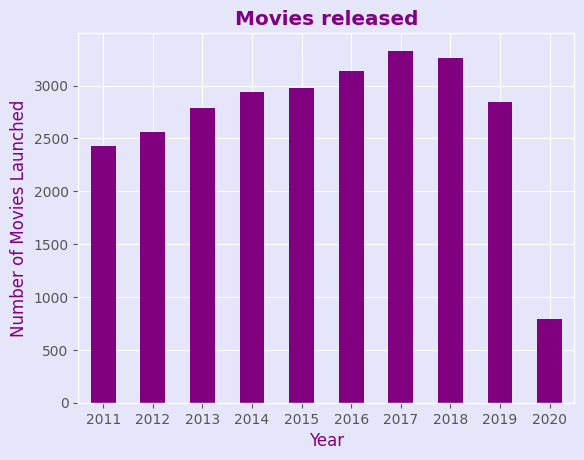

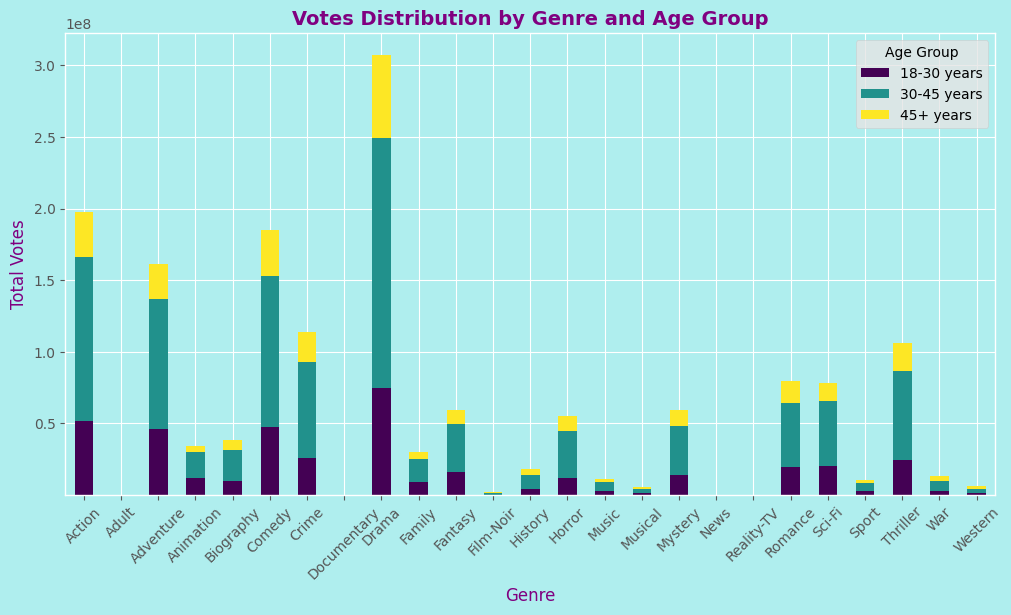

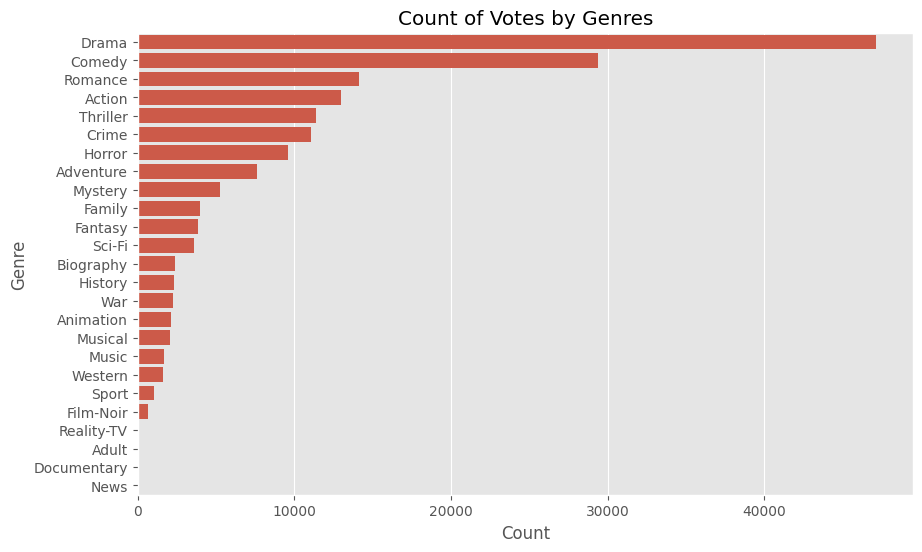

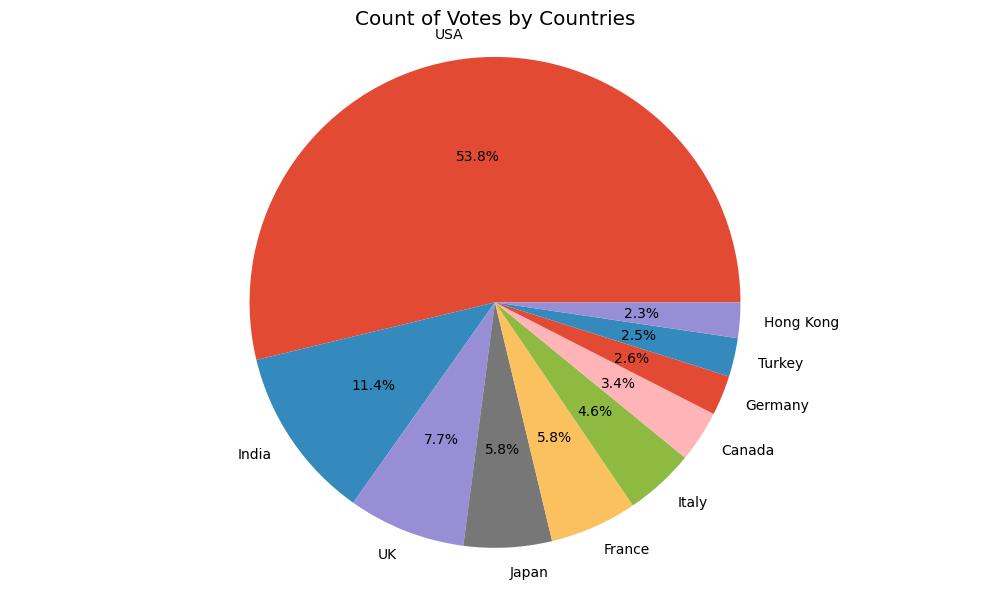

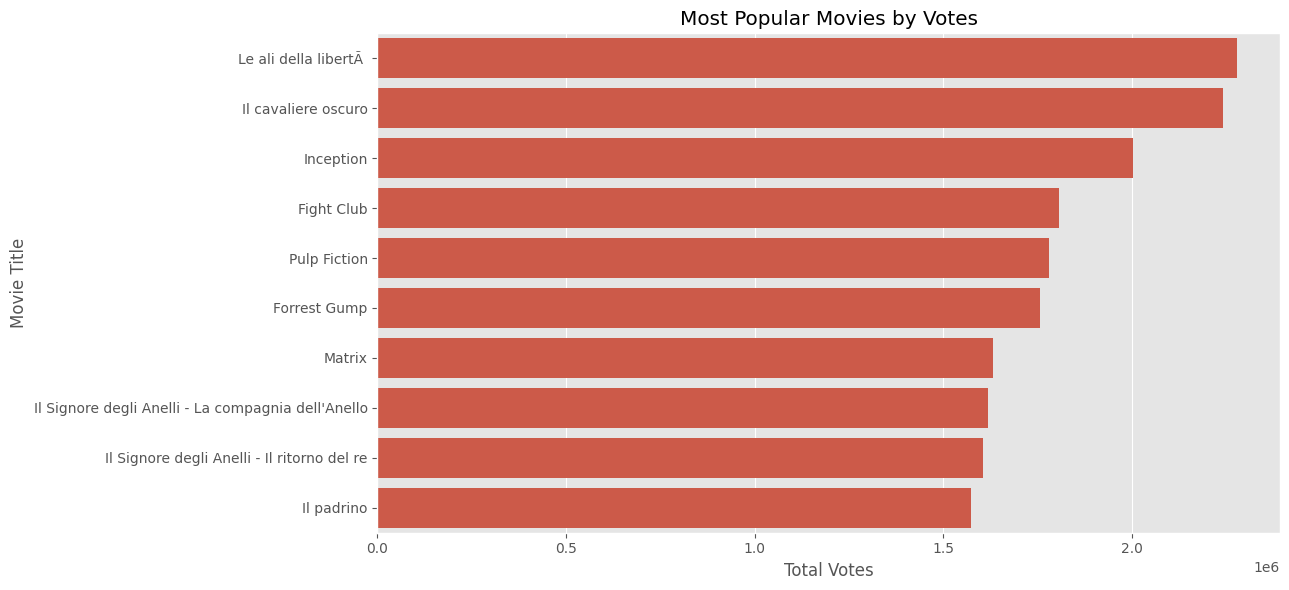

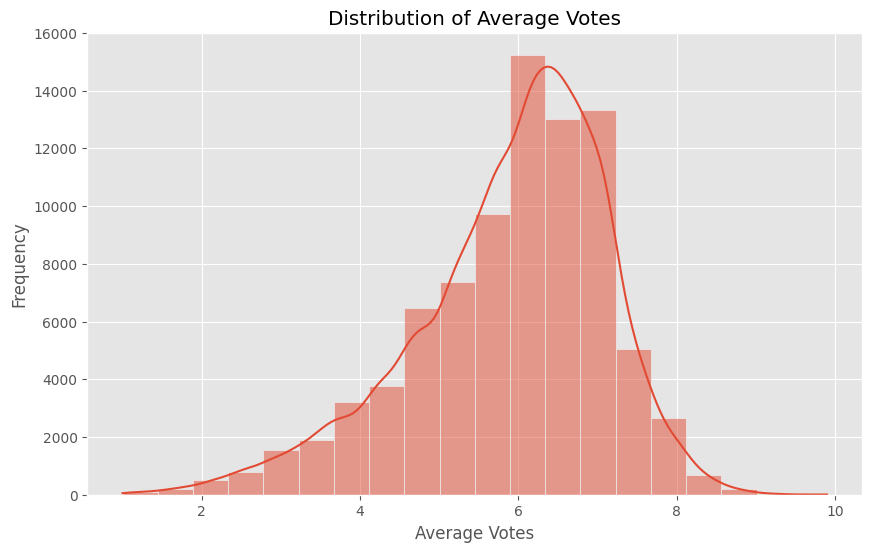

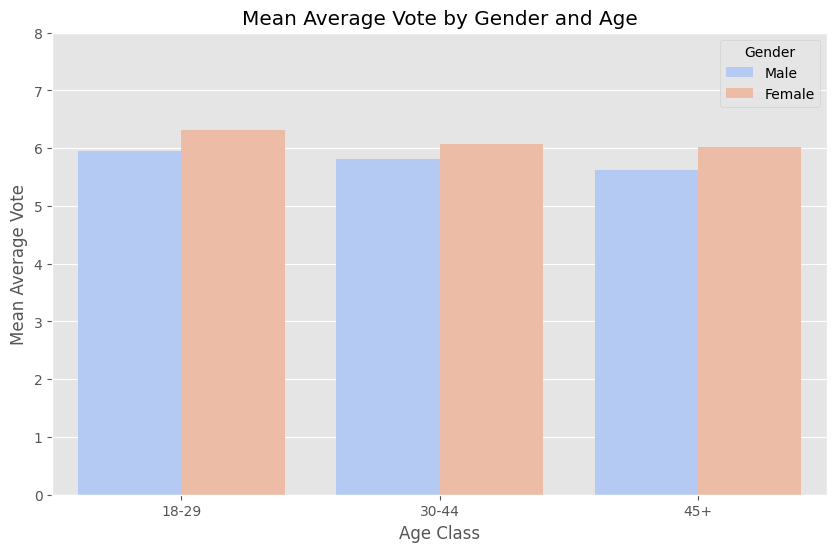

In [ ]:
#----- Graphics ----------------------------------------------------------------------------------------------------------------------------------------------------

# Coluna year:

graph_year_2009 = df['year'].value_counts().sort_index(ascending = True).head(10).plot(kind = 'bar', color = 'purple')

graph_year_2009.set_title('Movies released since 2009', color = 'purple', fontweight = 'bold')
graph_year_2009.set_xlabel('Year', color = 'purple')
graph_year_2009.set_ylabel('Number of Movies Launched', color = 'purple')
graph_year_2009.set_facecolor('lavender') # altera a cor dos quadradinhos por trás do gráfico


plt.gcf().set_facecolor('lavender')  # Altera a cor do fundo do gráfico em volta dos quadradinhos

#plt.show()

graph_year_1923 = df['year'].value_counts().sort_index(ascending = True).tail(10).plot(kind = 'bar', color = 'purple')

graph_year_1923.set_title('Movies released until 1923', color = 'purple', fontweight = 'bold')
graph_year_1923.set_xlabel('Year', color = 'purple')
graph_year_1923.set_ylabel('Number of Movies Launched', color = 'purple')
graph_year_1923.set_facecolor('lavender')

plt.gcf().set_facecolor('lavender')

#plt.show()

graph_year = df['year'].value_counts().sort_index().plot(kind='line', marker='o', color = 'purple')

graph_year.set_title('Movies released', color = 'purple', fontweight = 'bold')
graph_year.set_xlabel('Year', color = 'purple')
graph_year.set_ylabel('Number of Movies Launched', color = 'purple')
graph_year.set_facecolor('lavender') # altera a cor dos quadradinhos por trás do gráfico

plt.gcf().set_facecolor('lavender')

#plt.show()




# GRÁFICO DA MÉDIA DE VOTOS POR FAIXA ETÁRIA EM CADA GÉNERO:

# Criar uma cópia do DataFrame removendo valores nulos e separando os géneros
df_exploded = df.dropna(subset=['genre']).copy()
df_exploded['genre'] = df_exploded['genre'].str.split(', ')  # Separar géneros
df_exploded = df_exploded.explode('genre')  # Explodir para várias linhas

# Somar os votos por género e faixa etária
votos_por_genero = df_exploded.groupby('genre')[[
    'allgenders_18_to_30_votes',
    'allgenders_30_to_45_votes',
    'allgenders_45_and_above_votes'
]].sum()

# Criar gráfico de barras empilhadas
votos_por_genero.plot(kind = 'bar', stacked = True, figsize = (12, 6), colormap = 'viridis')

# Personalizar gráfico
plt.title('Votes Distribution by Genre and Age Group', fontsize = 14, fontweight = 'bold', color = 'purple')
plt.xlabel('Genre', color = 'purple')
plt.ylabel('Total Votes', color = 'purple')
plt.xticks(rotation = 45)  # Rodar os nomes do eixo dos x para melhor visualização
plt.legend(['18-30 years', '30-45 years', '45+ years'], title = "Age Group")

plt.gca().set_facecolor('paleturquoise')  # Cor dos quadrados do gráfico
plt.gcf().set_facecolor('paleturquoise')

#plt.show()



# Barplot with genres

# Note: the genres are separated by commas; .explode() splits the elements into new rows
genres_30 = datajoin['genre'].str.split(',').explode().str.strip().value_counts().head(30)
print(genres_30)

plt.figure(figsize = (10, 6))
barplot_genres = sns.barplot(x = genres_30.values, y = genres_30.index) 
plt.title('Count of Votes by Genres')
plt.xlabel('Count')
plt.ylabel('Genre')
# Note: bbox_inches='tight' removes unnecessary white spaces
plt.savefig(f"../figures/barplot_genres.png", bbox_inches = 'tight')
#plt.show()


# Pie chart with countries

countries_10 = datajoin['country'].value_counts().head(10)
#print(countries_10)

# Note: equal ensures that pie chart is drawn as a circle;
# %1.1f displays a decimal number with 1 decimal place; %% displays the % symbol
plt.figure(figsize = (10, 6))
plt.pie(countries_10, labels = countries_10.index, autopct = '%1.1f%%')
plt.title('Count of Votes by Countries')
plt.axis('equal')  
plt.tight_layout()
plt.savefig(f"../figures/piechart_coutries.png", bbox_inches = 'tight')
#plt.show() 


# Most popular movies

top_movies = datajoin.nlargest(10, 'total_votes')
#print(top_movies)

plt.figure(figsize = (13, 6))
sns.barplot(y = top_movies['title'], x = top_movies['total_votes'])
plt.title('Most Popular Movies by Votes')
plt.xlabel('Total Votes')
plt.ylabel('Movie Title')
plt.savefig(f"../figures/barplot_topmovies.png", bbox_inches = 'tight')
plt.tight_layout()
#plt.show()


# Distribution of average votes

# Note: kde = True creates a smoothed curve over the histogram
plt.figure(figsize = (10, 6))
sns.histplot(datajoin['avg_vote'], bins = 20, kde = True)
plt.title('Distribution of Average Votes')
plt.xlabel('Average Votes')
plt.ylabel('Frequency')
plt.savefig(f"../figures/hist_avgvotes.png", bbox_inches = 'tight')
#plt.show()


# Average votes by gender and age 

gender_age_ratings = pd.DataFrame({'Age Class': ['18-29', '30-44', '45+'],

                                    'Male': [datajoin['males_18age_avg_vote'].mean(),
                                             datajoin['males_30age_avg_vote'].mean(),
                                             datajoin['males_45age_avg_vote'].mean()],

                                    'Female': [datajoin['females_18age_avg_vote'].mean(),
                                                datajoin['females_30age_avg_vote'].mean(),
                                                datajoin['females_45age_avg_vote'].mean()]})

# Note: melt() unpivots the DataFrame from wide to long format
gender_age_ratings = gender_age_ratings.melt(id_vars = 'Age Class', var_name = 'Gender', value_name = 'Average Vote')
plt.figure(figsize = (10, 6))
sns.barplot(x = 'Age Class', y = 'Average Vote', hue = 'Gender', data = gender_age_ratings, palette = 'coolwarm')

plt.title('Mean Average Vote by Gender and Age')
plt.xlabel('Age Class')
plt.ylabel('Mean Average Vote')
plt.ylim(0, 8)
plt.legend(title = 'Gender')
plt.savefig(f"../figures/barplot_genderage.png", bbox_inches = 'tight')
plt.show()


In [11]:
# Guardar os dados tratados
datajoin.to_csv('../datasets/imdb_merged_filtrado.csv', index = False)